# CH 5 - 6 : ESTIMATION

## Objectif du notebook

Ce notebook transforme le concept d'**estimation statistique** en intuition concrète pour le trading.

Tu vas voir la différence entre :

- **le test d'hypothèse** : est-ce que mon edge semble exister ?
- **l'estimation** : quelle taille probable a mon edge ?
- **l'estimation ponctuelle** : un seul chiffre, souvent la moyenne du backtest.
- **l'estimation par intervalle** : une fourchette honnête qui reconnaît l'incertitude.

> Le test d'hypothèse répond : **"Est-ce que ce moteur tourne ?"**  
> L'estimation répond : **"Combien de chevaux il a vraiment ?"**


## 1. L'idée centrale

Quand tu fais un backtest, tu n'observes qu'un **échantillon** du comportement possible de ta stratégie.

Le vrai paramètre qui t'intéresse, lui, est invisible :

> **La performance future réelle de ta règle.**

Comme tu ne peux pas voir directement ce futur, tu utilises le passé pour l'approximer.

C'est ça, l'estimation.

| Élément | En trading |
|---|---|
| Population | Tous les trades futurs possibles de la stratégie |
| Échantillon | Les trades observés dans ton backtest |
| Paramètre | Le rendement moyen réel futur |
| Estimateur | La moyenne observée dans le backtest |
| Estimation | Le chiffre obtenu, par exemple +0.18R par trade |

Le danger, c'est de croire que le chiffre du backtest est la vérité exacte.

Ce n'est pas la vérité exacte.

C'est seulement la **meilleure approximation disponible**, avec une marge d'erreur.


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Paramètres cachés de la "vraie" stratégie.
# Dans la vraie vie, on ne les connaît pas.
true_mean_R = 0.15
true_std_R = 1.00
n_trades = 120

# Simulation d'un backtest
trades_R = np.random.normal(loc=true_mean_R, scale=true_std_R, size=n_trades)

point_estimate = trades_R.mean()
std_sample = trades_R.std(ddof=1)
standard_error = std_sample / np.sqrt(n_trades)

summary = pd.DataFrame({
    "Mesure": [
        "Nombre de trades",
        "Moyenne observée du backtest",
        "Écart-type observé",
        "Erreur standard de la moyenne"
    ],
    "Valeur": [
        n_trades,
        round(point_estimate, 4),
        round(std_sample, 4),
        round(standard_error, 4)
    ]
})

summary


,Mesure,Valeur
0,Nombre de trades,120.0000
1,Moyenne observée du backtest,0.0708
2,Écart-type observé,0.9253
3,Erreur standard de la moyenne,0.0845


## 2. Estimation ponctuelle : le chiffre unique

L'estimation ponctuelle, c'est quand tu dis :

> "Mon backtest montre une moyenne de +0.XXR par trade, donc ma meilleure estimation du futur est +0.XXR par trade."

C'est utile, mais incomplet.

Pourquoi ?

Parce que deux stratégies peuvent avoir la même moyenne observée, mais pas la même fiabilité.

Exemple :

- Stratégie A : +0.20R moyen sur 1 000 trades.
- Stratégie B : +0.20R moyen sur 20 trades.

Même chiffre.

Mais pas la même confiance.

La moyenne de la stratégie A est beaucoup plus solide, car elle repose sur plus d'observations.


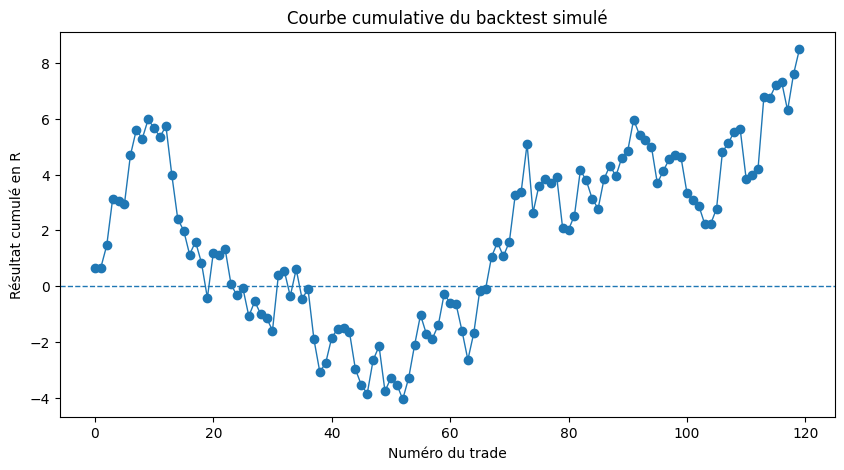

Estimation ponctuelle de l'espérance : 0.071R par trade


In [27]:
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(trades_R), marker="o", linewidth=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Courbe cumulative du backtest simulé")
plt.xlabel("Numéro du trade")
plt.ylabel("Résultat cumulé en R")
plt.show()

print(f"Estimation ponctuelle de l'espérance : {point_estimate:.3f}R par trade")


## 3. Pourquoi la moyenne d'échantillon est l'estimateur roi

Dans ce cadre, la moyenne est puissante parce qu'elle possède quatre qualités importantes.

### 1. Sans biais

Sur beaucoup de backtests indépendants, ses erreurs positives et négatives tendent à s'annuler.

### 2. Convergente

Plus tu ajoutes de trades, plus la moyenne observée se rapproche généralement de la vraie moyenne.

### 3. Efficiente

Elle utilise l'information de manière compacte et produit une estimation relativement stable.

### 4. Suffisante

Pour estimer une moyenne, elle concentre l'information utile contenue dans les observations.

> La moyenne n'est pas magique, mais c'est le meilleur résumé numérique de l'espérance d'une règle.


In [28]:
sample_sizes = [10, 20, 50, 100, 250, 500, 1000]
n_experiments = 3000

rows = []

for n in sample_sizes:
    means = []
    for _ in range(n_experiments):
        sample = np.random.normal(loc=true_mean_R, scale=true_std_R, size=n)
        means.append(sample.mean())

    means = np.array(means)
    rows.append({
        "Nombre de trades": n,
        "Moyenne des estimations": means.mean(),
        "Écart-type des estimations": means.std(ddof=1),
        "Erreur moyenne absolue": np.mean(np.abs(means - true_mean_R))
    })

convergence_table = pd.DataFrame(rows)
convergence_table.round(4)


,Nombre de trades,Moyenne des estimations,Écart-type des estimations,Erreur moyenne absolue
0,10,0.1495,0.3148,0.2547
1,20,0.1530,0.2304,0.1837
2,50,0.1504,0.1391,0.1111
3,100,0.1468,0.1012,0.0809
4,250,0.1483,0.0628,0.0499
5,500,0.1501,0.0443,0.0354
6,1000,0.1502,0.0309,0.0247


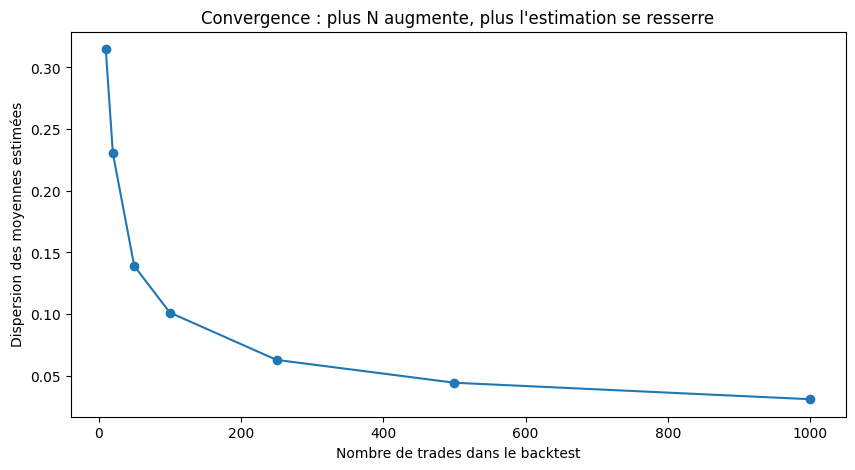

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(
    convergence_table["Nombre de trades"],
    convergence_table["Écart-type des estimations"],
    marker="o"
)
plt.title("Convergence : plus N augmente, plus l'estimation se resserre")
plt.xlabel("Nombre de trades dans le backtest")
plt.ylabel("Dispersion des moyennes estimées")
plt.show()


## 4. Estimation par intervalle : la version honnête

L'estimation ponctuelle dit :

> "Je pense que l'espérance est autour de +0.18R."

L'intervalle de confiance dit :

> "Compte tenu de l'incertitude, la vraie espérance plausible est peut-être entre +0.00R et +0.36R."

La deuxième phrase est plus utile pour un trader sérieux.

Elle t'empêche de surdimensionner ton risque sur un chiffre fragile.

Un intervalle large signifie :

- peu de trades,
- beaucoup de volatilité,
- résultats instables,
- forte incertitude.

Un intervalle étroit signifie :

- plus de trades,
- moins de bruit,
- estimation plus précise.


In [30]:
# Intervalle de confiance approximatif à 95 %
# Formule simple : moyenne ± 1.96 * erreur standard
ci_low = point_estimate - 1.96 * standard_error
ci_high = point_estimate + 1.96 * standard_error

print(f"Estimation ponctuelle : {point_estimate:.3f}R par trade")
print(f"Intervalle de confiance 95 % approximatif : [{ci_low:.3f}R ; {ci_high:.3f}R]")
print(f"Vraie moyenne cachée de la simulation : {true_mean_R:.3f}R")


Estimation ponctuelle : 0.071R par trade
Intervalle de confiance 95 % approximatif : [-0.095R ; 0.236R]
Vraie moyenne cachée de la simulation : 0.150R


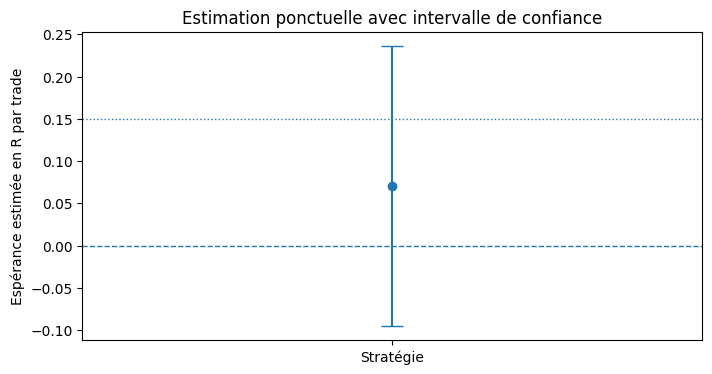

In [31]:
plt.figure(figsize=(8, 4))
plt.errorbar(
    x=[1],
    y=[point_estimate],
    yerr=[[point_estimate - ci_low], [ci_high - point_estimate]],
    fmt="o",
    capsize=8
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(true_mean_R, linestyle=":", linewidth=1)
plt.xlim(0.5, 1.5)
plt.xticks([1], ["Stratégie"])
plt.title("Estimation ponctuelle avec intervalle de confiance")
plt.ylabel("Espérance estimée en R par trade")
plt.show()


## 5. Bootstrap : construire une fourchette sans supposer une courbe parfaite

En trading, les résultats ne suivent pas toujours une belle distribution normale.

Tu peux avoir :

- des gros gagnants rares,
- des pertes en série,
- des queues épaisses,
- de l'asymétrie,
- des conditions de marché changeantes.

Le Bootstrap est utile car il crée une distribution d'estimations à partir de tes propres trades.

Principe :

1. Tu prends tes trades de backtest.
2. Tu tires au hasard des trades avec remise.
3. Tu reconstruis un faux backtest de même taille.
4. Tu calcules sa moyenne.
5. Tu répètes des milliers de fois.
6. Tu regardes la distribution des moyennes obtenues.

Cette distribution représente le flou autour de ton estimation.


In [32]:
n_bootstrap = 10000
bootstrap_means = []

for _ in range(n_bootstrap):
    boot_sample = np.random.choice(trades_R, size=n_trades, replace=True)
    bootstrap_means.append(boot_sample.mean())

bootstrap_means = np.array(bootstrap_means)

boot_low, boot_high = np.percentile(bootstrap_means, [2.5, 97.5])

print(f"Estimation ponctuelle : {point_estimate:.3f}R")
print(f"Intervalle bootstrap 95 % : [{boot_low:.3f}R ; {boot_high:.3f}R]")


Estimation ponctuelle : 0.071R
Intervalle bootstrap 95 % : [-0.093R ; 0.234R]


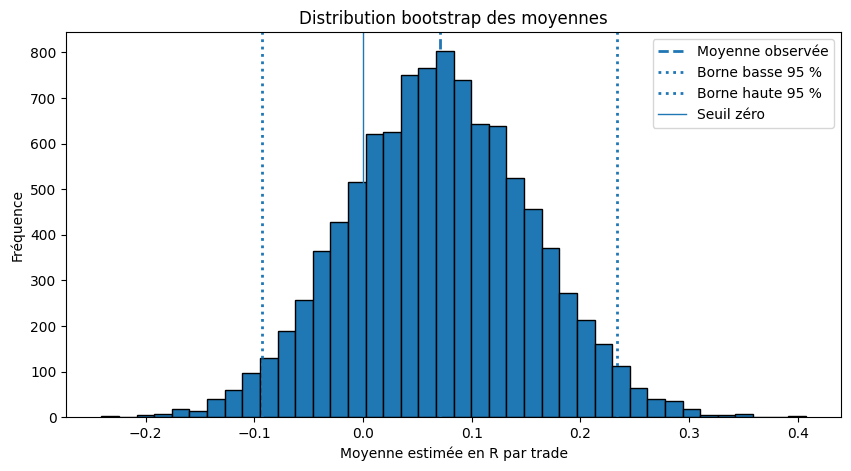

In [33]:
plt.figure(figsize=(10, 5))
plt.hist(bootstrap_means, bins=40, edgecolor="black")
plt.axvline(point_estimate, linestyle="--", linewidth=2, label="Moyenne observée")
plt.axvline(boot_low, linestyle=":", linewidth=2, label="Borne basse 95 %")
plt.axvline(boot_high, linestyle=":", linewidth=2, label="Borne haute 95 %")
plt.axvline(0, linestyle="-", linewidth=1, label="Seuil zéro")
plt.title("Distribution bootstrap des moyennes")
plt.xlabel("Moyenne estimée en R par trade")
plt.ylabel("Fréquence")
plt.legend()
plt.show()


## 6. Lecture trading : comment décider avec l'intervalle ?

Imagine que ton backtest donne :

> Estimation ponctuelle = +0.20R par trade.

Tu pourrais être tenté de dire :

> "Mon edge est de +0.20R, je peux augmenter le risque."

Mais l'intervalle peut raconter trois histoires différentes.

### Cas A : intervalle entièrement positif

Exemple : `[+0.08R ; +0.32R]`

L'edge semble robuste. Même l'hypothèse prudente reste positive.

### Cas B : intervalle positif mais proche de zéro

Exemple : `[+0.01R ; +0.39R]`

L'edge existe peut-être, mais il faut rester prudent. La borne basse est fragile.

### Cas C : intervalle traverse zéro

Exemple : `[-0.05R ; +0.45R]`

Ton backtest est peut-être bon, mais l'incertitude est encore trop grande.

Ce n'est pas forcément une mauvaise stratégie.

Mais ce n'est pas encore une stratégie à dimensionner agressivement.


In [34]:
examples = pd.DataFrame({
    "Cas": ["A - Robuste", "B - Fragile", "C - Incertain"],
    "Estimation ponctuelle": [0.20, 0.20, 0.20],
    "Borne basse": [0.08, 0.01, -0.05],
    "Borne haute": [0.32, 0.39, 0.45],
    "Lecture trader": [
        "Edge probablement exploitable",
        "Edge positif mais prudence",
        "Incertitude trop forte"
    ]
})

examples


,Cas,Estimation ponctuelle,Borne basse,Borne haute,Lecture trader
0,A - Robuste,0.2,0.08,0.32,Edge probablement exploitable
1,B - Fragile,0.2,0.01,0.39,Edge positif mais prudence
2,C - Incertain,0.2,-0.05,0.45,Incertitude trop forte


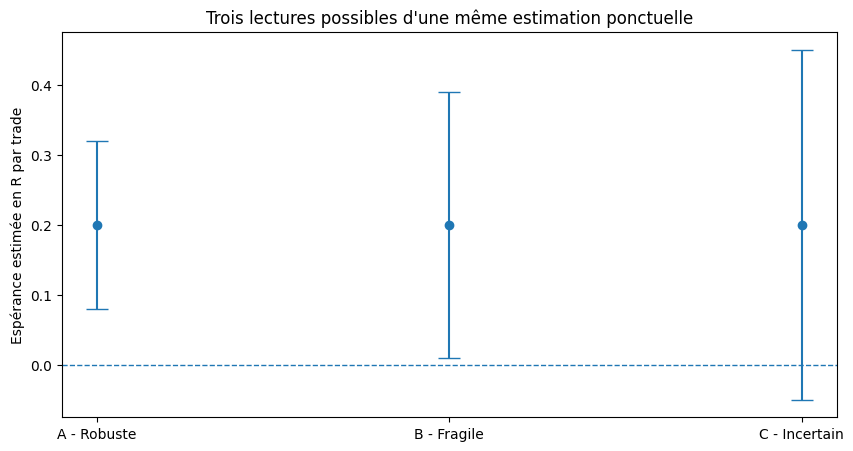

In [35]:
plt.figure(figsize=(10, 5))

x = np.arange(len(examples))
y = examples["Estimation ponctuelle"].values
yerr_low = y - examples["Borne basse"].values
yerr_high = examples["Borne haute"].values - y

plt.errorbar(x, y, yerr=[yerr_low, yerr_high], fmt="o", capsize=8)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(x, examples["Cas"])
plt.title("Trois lectures possibles d'une même estimation ponctuelle")
plt.ylabel("Espérance estimée en R par trade")
plt.show()


## 7. Mini-backtest complet : estimation d'une stratégie

Dans cette section, on simule une stratégie avec :

- signaux aléatoires pour l'exemple,
- rendements journaliers,
- résultats en R,
- estimation ponctuelle,
- intervalle bootstrap.

Le but n'est pas de créer une vraie stratégie rentable.

Le but est de montrer le protocole EBTA :

> Ne jamais s'arrêter au chiffre moyen. Toujours mesurer l'incertitude autour du chiffre.


In [36]:
np.random.seed(123)

n = 250

# Simulation de rendements journaliers du marché
market_returns = np.random.normal(loc=0.0002, scale=0.01, size=n)

# Simulation d'un signal de trading : -1, 0, +1
signals = np.random.choice([-1, 0, 1], size=n, p=[0.35, 0.30, 0.35])

# Ajout d'un petit edge artificiel quand le signal est actif
edge = 0.0015 * np.abs(signals)

strategy_returns = signals * market_returns + edge
strategy_R = strategy_returns / 0.01

strategy_mean = strategy_R.mean()

boot_means_strategy = []
for _ in range(10000):
    sample = np.random.choice(strategy_R, size=len(strategy_R), replace=True)
    boot_means_strategy.append(sample.mean())

boot_means_strategy = np.array(boot_means_strategy)
strategy_low, strategy_high = np.percentile(boot_means_strategy, [2.5, 97.5])

print(f"Estimation ponctuelle : {strategy_mean:.4f}R par jour")
print(f"Intervalle bootstrap 95 % : [{strategy_low:.4f}R ; {strategy_high:.4f}R]")


Estimation ponctuelle : 0.0694R par jour
Intervalle bootstrap 95 % : [-0.0329R ; 0.1721R]


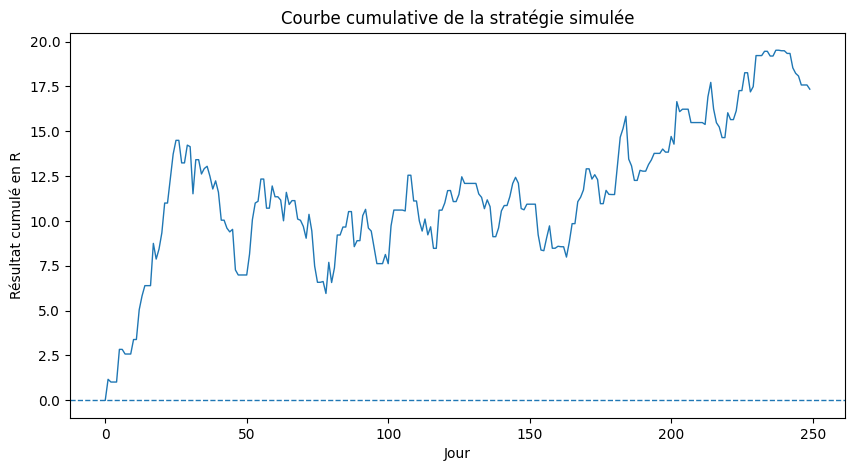

In [37]:
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(strategy_R), linewidth=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Courbe cumulative de la stratégie simulée")
plt.xlabel("Jour")
plt.ylabel("Résultat cumulé en R")
plt.show()


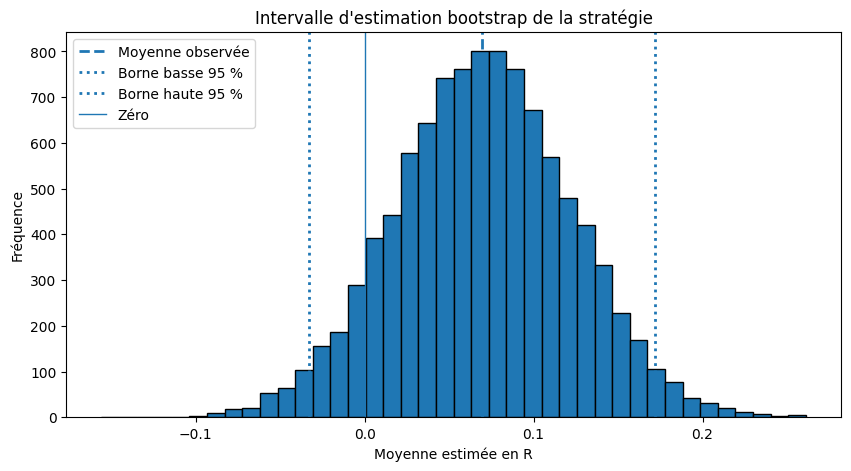

In [38]:
plt.figure(figsize=(10, 5))
plt.hist(boot_means_strategy, bins=40, edgecolor="black")
plt.axvline(strategy_mean, linestyle="--", linewidth=2, label="Moyenne observée")
plt.axvline(strategy_low, linestyle=":", linewidth=2, label="Borne basse 95 %")
plt.axvline(strategy_high, linestyle=":", linewidth=2, label="Borne haute 95 %")
plt.axvline(0, linestyle="-", linewidth=1, label="Zéro")
plt.title("Intervalle d'estimation bootstrap de la stratégie")
plt.xlabel("Moyenne estimée en R")
plt.ylabel("Fréquence")
plt.legend()
plt.show()


## 8. La phrase qui doit rester

Une stratégie validée statistiquement peut encore être difficile à dimensionner si son estimation est floue.

Le bon réflexe EBTA est donc :

1. **Tester** : est-ce que la performance semble trop bonne pour être seulement du hasard ?
2. **Estimer** : quelle est la taille probable de cette performance ?
3. **Encadrer** : quelle est la fourchette réaliste autour de cette performance ?
4. **Dimensionner prudemment** : utiliser la borne basse comme scénario conservateur.

En pratique, ne te demande pas seulement :

> "Combien mon backtest a gagné ?"

Demande-toi aussi :

> "Quelle est la plus petite performance plausible compatible avec mes données ?"

C'est cette question qui protège ton capital.


## 9. Checklist pratique EBTA

Avant de trader une règle, vérifie :

- Ai-je une estimation ponctuelle claire ?
- Ai-je un intervalle de confiance ?
- L'intervalle traverse-t-il zéro ?
- La borne basse reste-t-elle acceptable ?
- Mon nombre de trades est-il suffisant ?
- La volatilité des trades rend-elle l'estimation trop large ?
- Est-ce que je dimensionne mon risque sur la moyenne ou sur un scénario prudent ?

La moyenne te donne l'espoir.

L'intervalle te donne la lucidité.


## 10. Résumé ultra-simple

| Concept | Question | Exemple |
|---|---|---|
| Test d'hypothèse | Est-ce que ça marche ? | p-value < 0.05 |
| Estimation ponctuelle | Combien ça rapporte en moyenne ? | +0.20R/trade |
| Estimation par intervalle | Quelle est la fourchette plausible ? | [+0.05R ; +0.35R] |
| Bootstrap | Comment mesurer l'incertitude sans hypothèse trop rigide ? | Rééchantillonnage des trades |
| Borne basse | Quel scénario prudent dois-je respecter ? | +0.05R/trade |

Phrase finale :

> **Un backtest donne un chiffre. L'estimation transforme ce chiffre en décision prudente.**


---
## 📎 Annexe – Source originale (à titre de référence)

> **Note**: Cette annexe reprend le texte source original. Elle est conservée pour la traçabilité, mais la version lisible suit ci‑dessus.

### 📄 Source brute (markdown)

```markdown
/codeexemple
### **CH 5 - 6 : ESTIMATION**

Voici l’analyse technique de l’estimation, le second pilier de l’inférence statistique qui permet de quantifier la performance future probable d’une règle de trading après sa validation.

#### **Idées clés :**
* **Mesure de l'ampleur** – L’estimation quantifie la taille de l’effet (ex. profit attendu).
* **Lien avec le paramètre** – Utilise le backtest pour approximer le rendement réel futur.
* **Deux formats** – Ponctuel (un chiffre) ou intervalle (fourchette).
* **Supériorité de la moyenne** – Estimateur sans biais, convergent, efficient et suffisant.

#### **Référence :**
*ESTIMATION*, Chapitre 5, pages 243‑245.

#### **Citation directe :**
« A hypothesis test tells us if an effect is present or not, whereas an estimate tells us about the size of an effect. […] In our case, it will be used to estimate the expected return of a rule. » (Pages 217 et 243).

---

#### **Vision macro**
Passer de la détection à la planification : l’estimation fournit une projection financière exploitable et quantifie l’incertitude.

---

#### **Vision micro**
1. **Estimation ponctuelle** – Valeur unique (ex. +10 %). Critères : *unbiased*, *consistent*, *efficient*, *sufficient*.
2. **Estimation par intervalle** – Fourchette avec niveau de confiance (ex. 95 %). Largeur issue de la distribution d’échantillonnage (souvent Bootstrap).

---

#### **Résumé simplifié**
Le test d’hypothèse juge la présence d’un edge. L’estimation mesure son amplitude. L’estimation ponctuelle donne un chiffre ; l’estimation intervalle indique une fourchette réaliste (ex. 5 %‑15 %).

---

#### **Actions concrètes**
* Ne pas trader uniquement sur l’estimation ponctuelle.
* Privilégier la moyenne arithmétique.
* Utiliser le Bootstrap pour des intervalles robustes.
* Augmenter la taille de l’échantillon pour réduire l’incertitude.

---

#### **À retenir absolument**
* **Test** = Est‑ce que ça marche ? / **Estimation** = Combien ça rapporte ?
* La **moyenne d’échantillon** est l’estimateur « roi » en EBTA.
* L’**intervalle de confiance** mesure rigoureusement l’incertitude.
* Plus la volatilité est élevée, plus l’intervalle s’élargit.
```

---
